# Prediksi Diabetes dengan XGBoost

Kelompok B3:

- <2310512072@mahasiswa.upnvj.ac.id> (Thara Carissa Khameshwara)
- <2310512075@mahasiswa.upnvj.ac.id> (Ausath Abdi Dzil Ikram )
- <2310512083@mahasiswa.upnvj.ac.id> (Annabelle Evrilya Savhisnu)
- <2310512097@mahasiswa.upnvj.ac.id> (Yessa Chronika Natalin Sagala)
- <2310512108@mahasiswa.upnvj.ac.id> (Vega Setiawan)

Program Studi S1 Sistem Informasi, Fakultas Ilmu Komputer, Universitas Pembangunan Nasional "Veteran" Jakarta

Tahun 2026

## Business Understanding

### Latar Belakang

Prevalensi diabetes secara global terus meningkat, memicu komplikasi fatal dan membebani sistem kesehatan. Deteksi dini sangat esensial, namun tes darah klinis berskala massal tidak efisien secara biaya. Oleh karena itu, diperlukan pendekatan skrining awal alternatif berskala besar yang efisien berbasis indikator gaya hidup dan demografi.

### Dataset

Penelitian ini menggunakan dataset Behavioral Risk Factor Surveillance System (BRFSS) 2015 dari CDC Amerika Serikat. Data bersumber dari respons survei terkait status kesehatan dan kebiasaan hidup. Tantangan teknis utama dataset ini adalah ketidakseimbangan kelas (*class imbalance*) yang ekstrem: 83% responden tergolong non-diabetes dan hanya 17% penderita diabetes.

### Tujuan Bisnis (*Business Objectives*)

Mengembangkan prototipe sistem peringatan dini (*early-warning system*) untuk skrining kesehatan berskala populasi. Sistem ditargetkan mampu mengidentifikasi individu berisiko tinggi tanpa intervensi klinis awal, memungkinkan fasilitas kesehatan memprioritaskan alokasi rujukan medis lanjutan secara terarah.

### Tujuan Data Mining (*Data Mining Objectives*)

Membangun model *Machine Learning* untuk mengklasifikasikan risiko diabetes. Objektif teknis mencakup mitigasi ketidakseimbangan data via SMOTEENN, optimasi algoritma *tree-based* (Random Forest dan XGBoost), serta penerapan *Explainable AI* (SHAP) untuk transparansi interpretasi klinis.

### Kriteria Keberhasilan (*Success Criteria*)

- **Kriteria Bisnis:** Mengekstraksi *actionable insights* mengenai faktor risiko determinan untuk edukasi preventif.
- **Kriteria Model:** Menghindari bias metrik Akurasi global. Keberhasilan diukur melalui pencapaian skor *Recall* yang krusial (minimal 70%) untuk meminimalisasi *False Negatives*, didukung oleh konsistensi metrik ROC AUC (~0.80) tanpa indikasi *data leakage*.

### Batasan Riset (*Limitations*)

- **Non-Diagnostik:** Model berfungsi eksklusif sebagai alat penapisan (triase), bukan pengganti uji klinis.
- **Bias Pelaporan:** Dataset berbasis pelaporan mandiri (*self-reported*) rentan terhadap deviasi subjektif responden.
- **Kapasitas Prediktif:** Ketiadaan rekam medis membatasi ambang performa teoritis model (estimasi maksimal ROC AUC ~0.80) dalam mendeteksi anomali patologis.

## Data Understanding

In [2]:
import pandas as pd

df = pd.read_csv('../data/clean_dataset.csv')

print(f"DataFrame shape: {df.shape}")
print("\nDataFrame info:")
df.info()

print("\nMissing values:")
df.isnull().sum()

DataFrame shape: (234034, 22)

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 234034 entries, 0 to 234033
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       234034 non-null  float64
 1   HighBP                234034 non-null  float64
 2   HighChol              234034 non-null  float64
 3   CholCheck             234034 non-null  float64
 4   BMI                   234034 non-null  float64
 5   Smoker                234034 non-null  float64
 6   Stroke                234034 non-null  float64
 7   HeartDiseaseorAttack  234034 non-null  float64
 8   PhysActivity          234034 non-null  float64
 9   Fruits                234034 non-null  float64
 10  Veggies               234034 non-null  float64
 11  HvyAlcoholConsump     234034 non-null  float64
 12  AnyHealthcare         234034 non-null  float64
 13  NoDocbcCost           234034 non-null  float64
 14  GenHlth         

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Hasil eksekusi mengonfirmasi struktur akhir dataset: **234.034 observasi** dan **22 variabel**. Nihilnya *missing values* dan presisi tipe data memvalidasi keberhasilan *pipeline* pembersihan data awal. Dataset sepenuhnya siap untuk analisis dan pemodelan prediktif.

In [3]:
from IPython.display import display

print("Numerical features summary:")
display(df.describe())

Numerical features summary:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,234034.000000,234034.000000,234034.000000,234034.000000,234034.000000,234034.000000,234034.000000,234034.00000,234034.000000,234034.000000,...,234034.000000,234034.00000,234034.000000,234034.000000,234034.000000,234034.000000,234034.000000,234034.000000,234034.000000,234034.000000
mean,0.169450,0.457737,0.445123,0.960006,28.727869,0.466360,0.045070,0.10413,0.731889,0.612415,...,0.945978,0.09367,2.609275,3.531115,4.715473,0.187618,0.438966,8.104199,4.975692,5.877582
std,0.375149,0.498212,0.496980,0.195946,6.799401,0.498868,0.207459,0.30543,0.442976,0.487200,...,0.226062,0.29137,1.065605,7.744930,9.081022,0.390408,0.496262,3.089272,0.995056,2.096647
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,1.000000,0.00000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,4.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.00000,1.000000,1.000000,...,1.000000,0.00000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.000000,0.000000,0.00000,1.000000,1.000000,...,1.000000,0.00000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.00000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Tinjauan statistik deskriptif menunjukkan rentang nilai observasi yang logis. Mayoritas fitur bersifat biner dan ordinal, dengan beberapa variabel kontinu (contoh: BMI). Nilai rata-rata target (`Diabetes_binary`) tercatat pada **0.169**, merepresentasikan proporsi kelas minoritas (16.9%) pada populasi.

Class distribution:


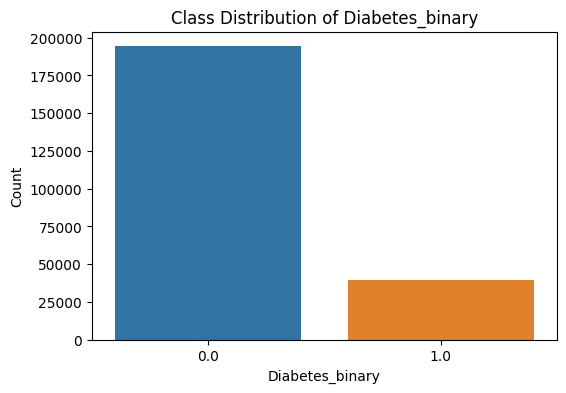

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Class distribution:")
df['Diabetes_binary'].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Diabetes_binary', hue='Diabetes_binary', legend=False)
plt.title('Class Distribution of Diabetes_binary')
plt.xlabel('Diabetes_binary')
plt.ylabel('Count')
plt.show()

Visualisasi distribusi target menegaskan kehadiran **Ketidakseimbangan Kelas (*Class Imbalance*) Ekstrem**. Dominasi kelas negatif (83%) berpotensi memicu bias prediksi (*accuracy paradox*). Implementasi metode *resampling* seperti SMOTEENN merupakan keharusan metodologis guna memitigasi anomali klasifikasi.

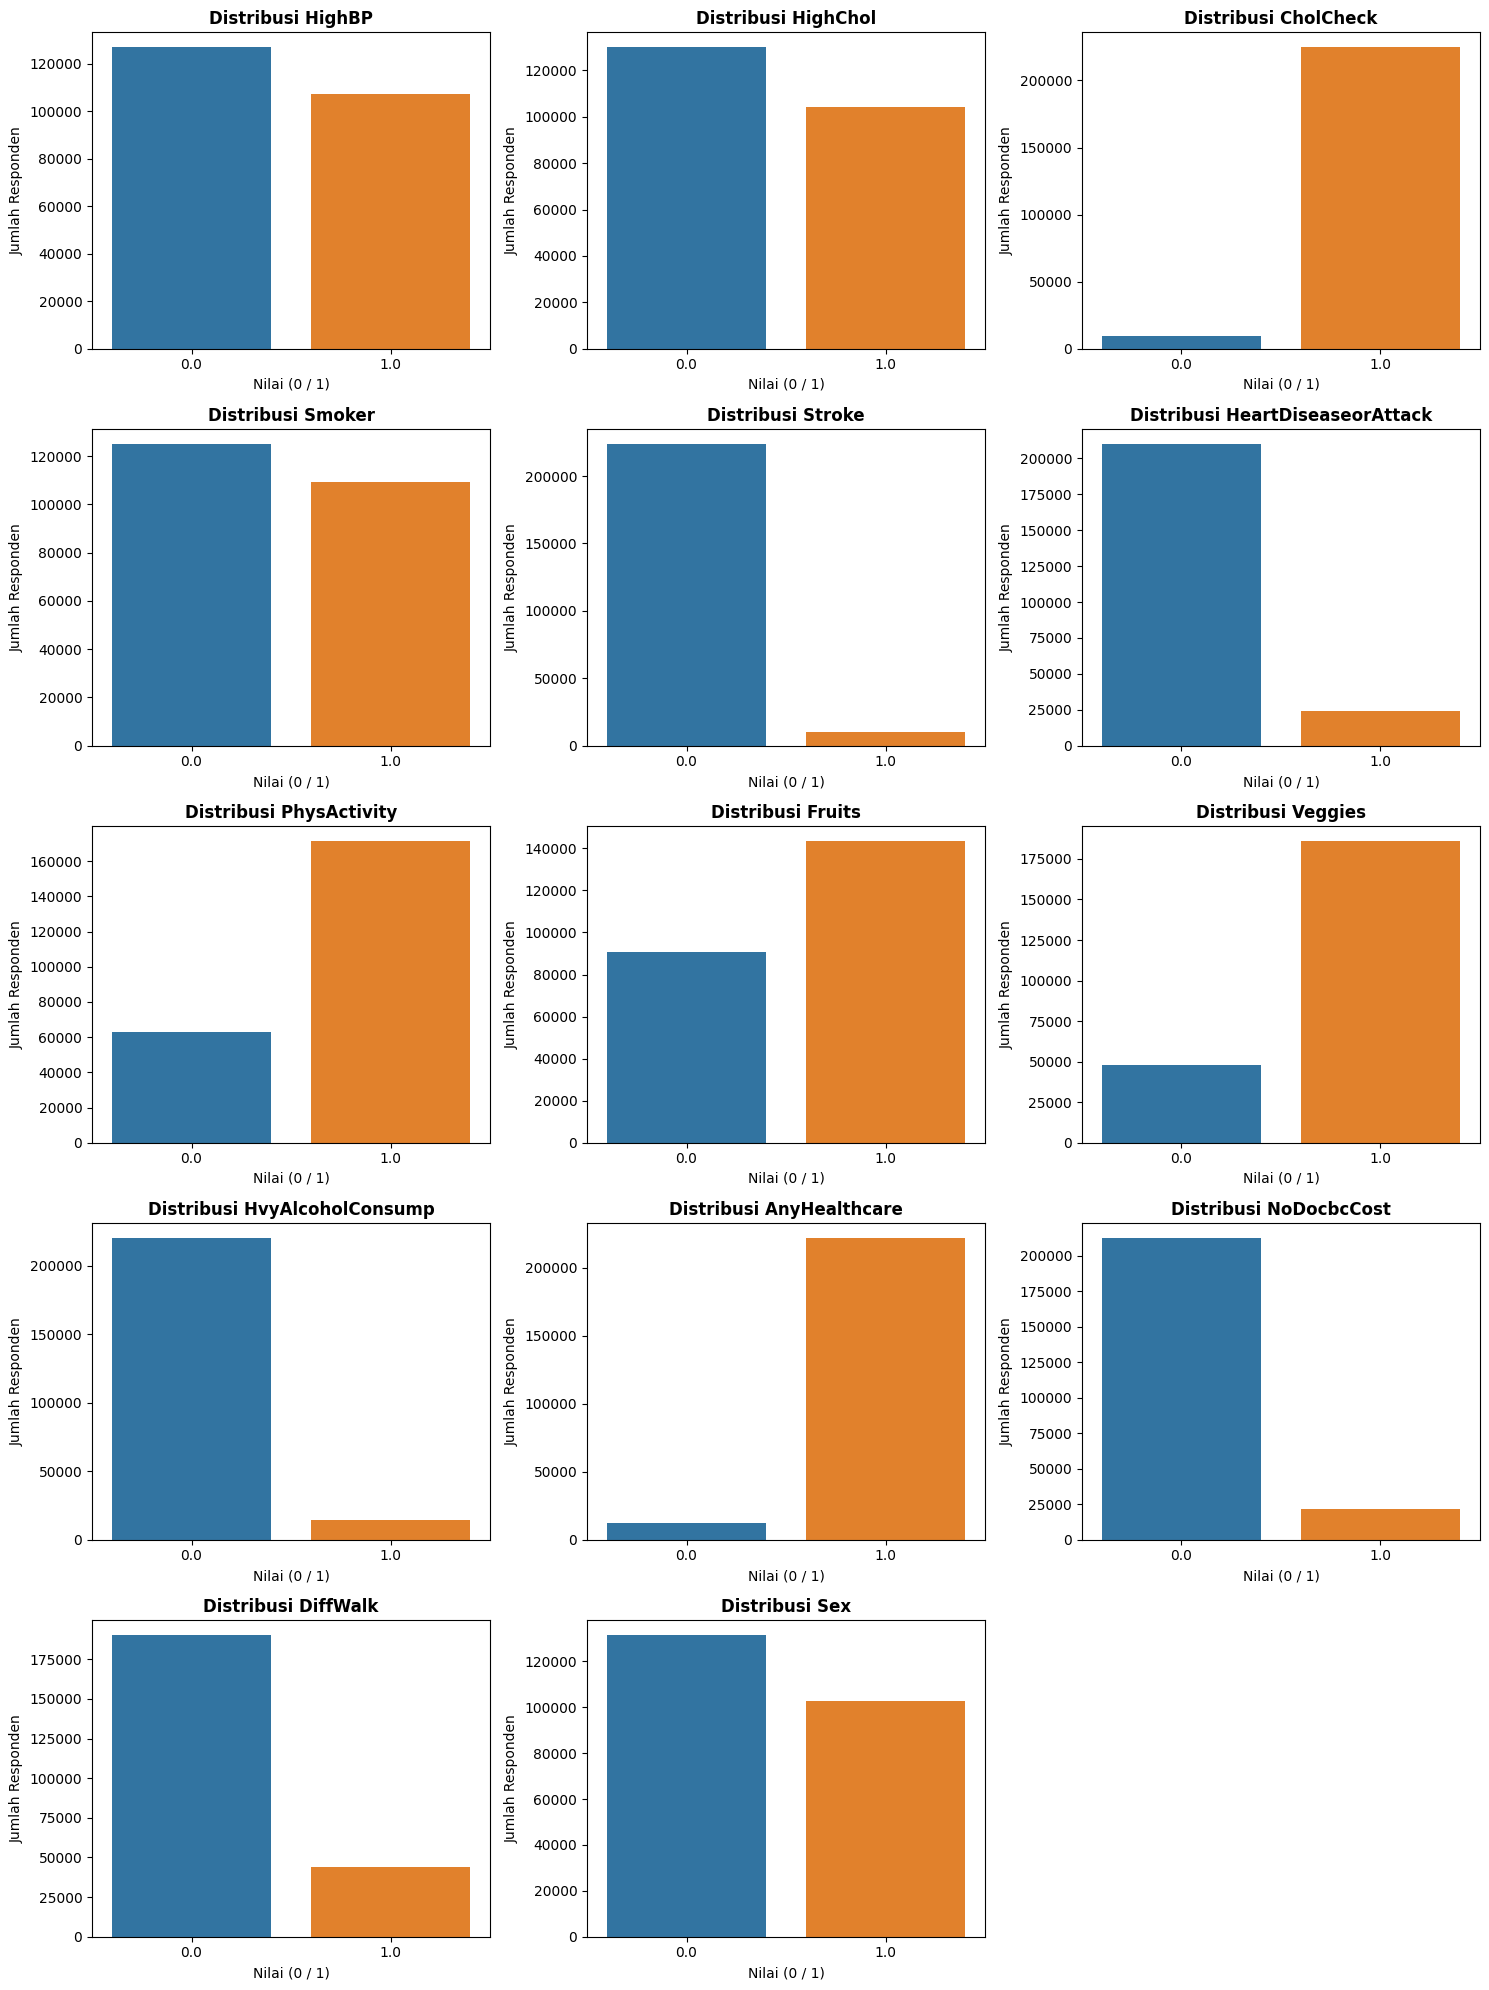

In [45]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and col != 'Diabetes_binary']

n_cols = 3
n_rows = (len(binary_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.countplot(x=col, data=df, ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Nilai (0 / 1)')
    axes[i].set_ylabel('Jumlah Responden')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

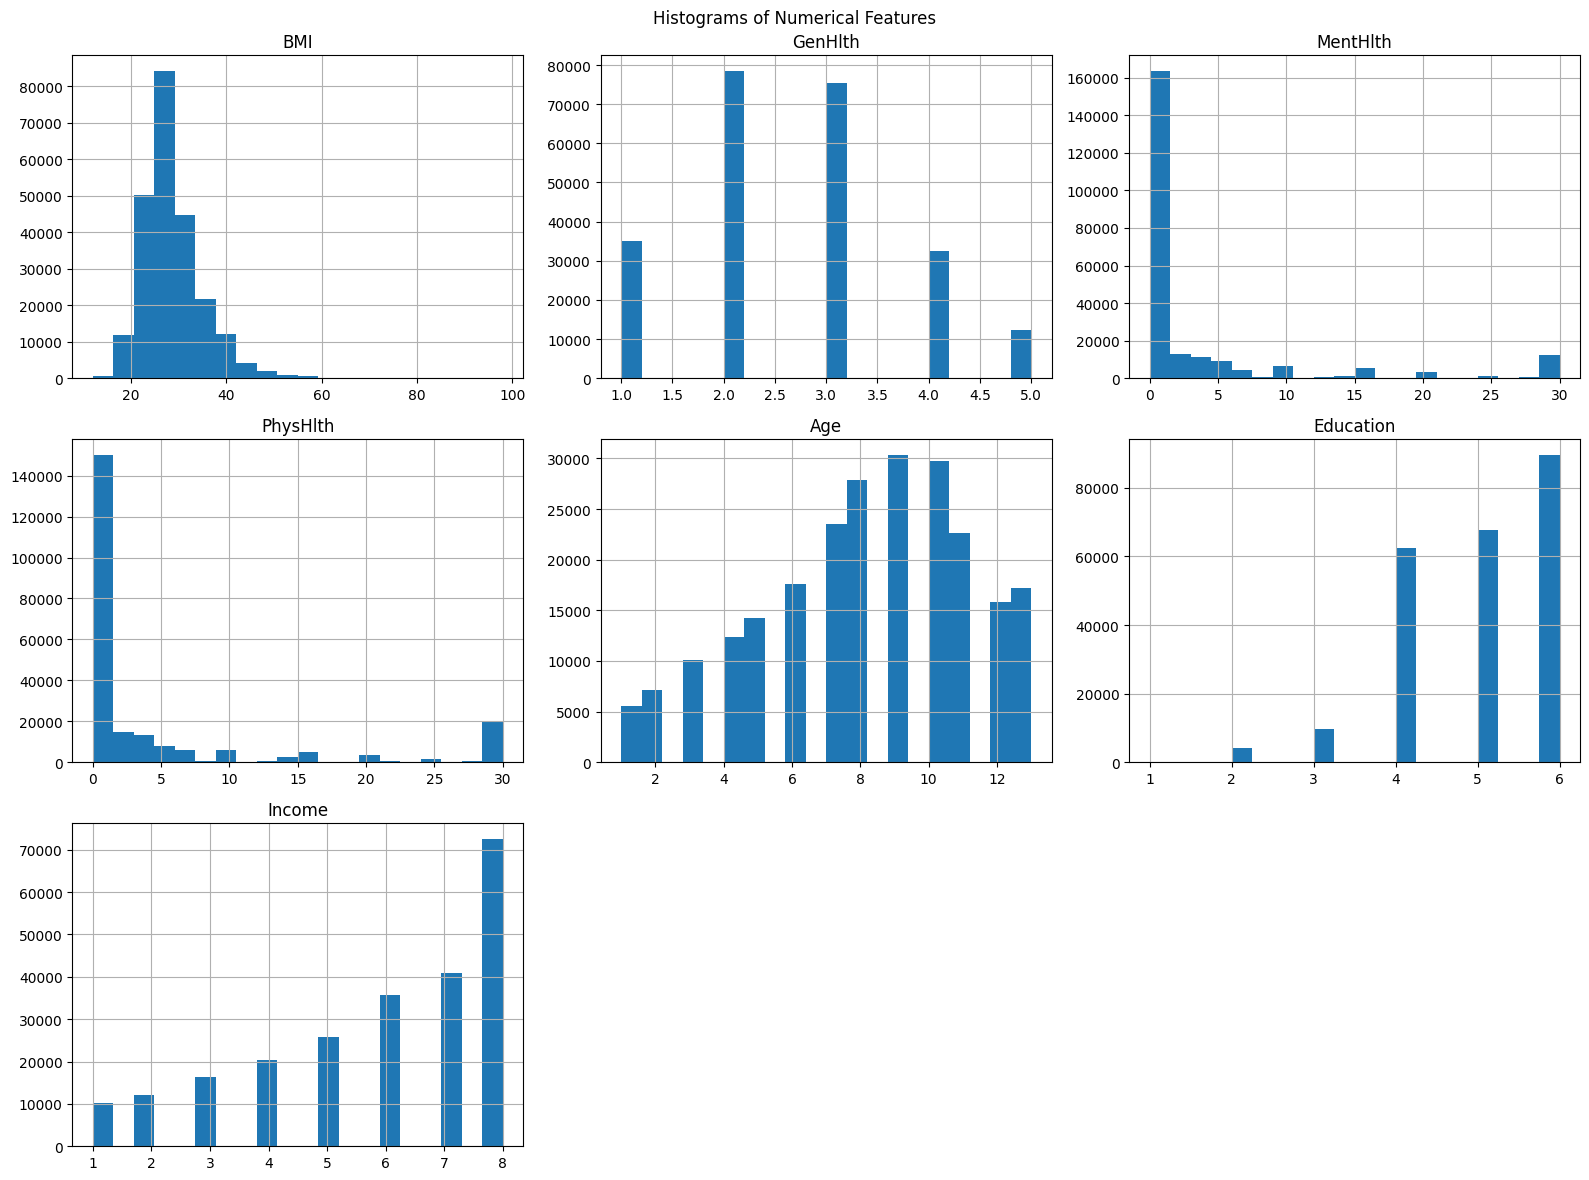

In [42]:
numerical_features = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

df[numerical_features].hist(figsize=(16, 12), bins=20)
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

Distribusi variabel prediktor numerik non binary menunjukkan variansi yang relevan:

- Variabel kontinu seperti **BMI** berdistribusi condong ke kanan (*right-skewed*), mencerminkan subpopulasi obesitas ekstrem.
- Variabel ordinal seperti **Age** (Usia) condong ke kiri (*left-skewed*), mengonfirmasi dominasi demografi paruh baya hingga lanjut usia yang berisiko tinggi.

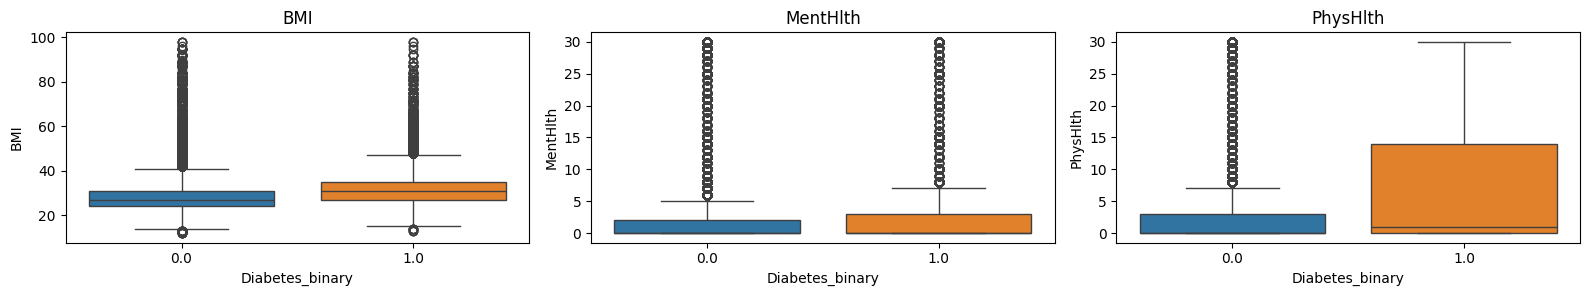

In [41]:
# Non binary features
features_to_plot = ['BMI', 'MentHlth', 'PhysHlth']

plt.figure(figsize=(16, 8))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='Diabetes_binary', y=feature, hue='Diabetes_binary', legend=False)
    plt.title(feature)

plt.tight_layout()
plt.show()

Analisis *Boxplot* mendeteksi kehadiran *outliers* pada variabel numerik kontinu. Dalam ranah medis, observasi ekstrem pada BMI atau status kesehatan merupakan potret klinis yang valid (patologis), bukan anomali struktural (*noise*). Oleh karena itu, observasi ini dipertahankan, mempertimbangkan ketangguhan (*robustness*) algoritma *tree-based* terhadap data ekstrem.

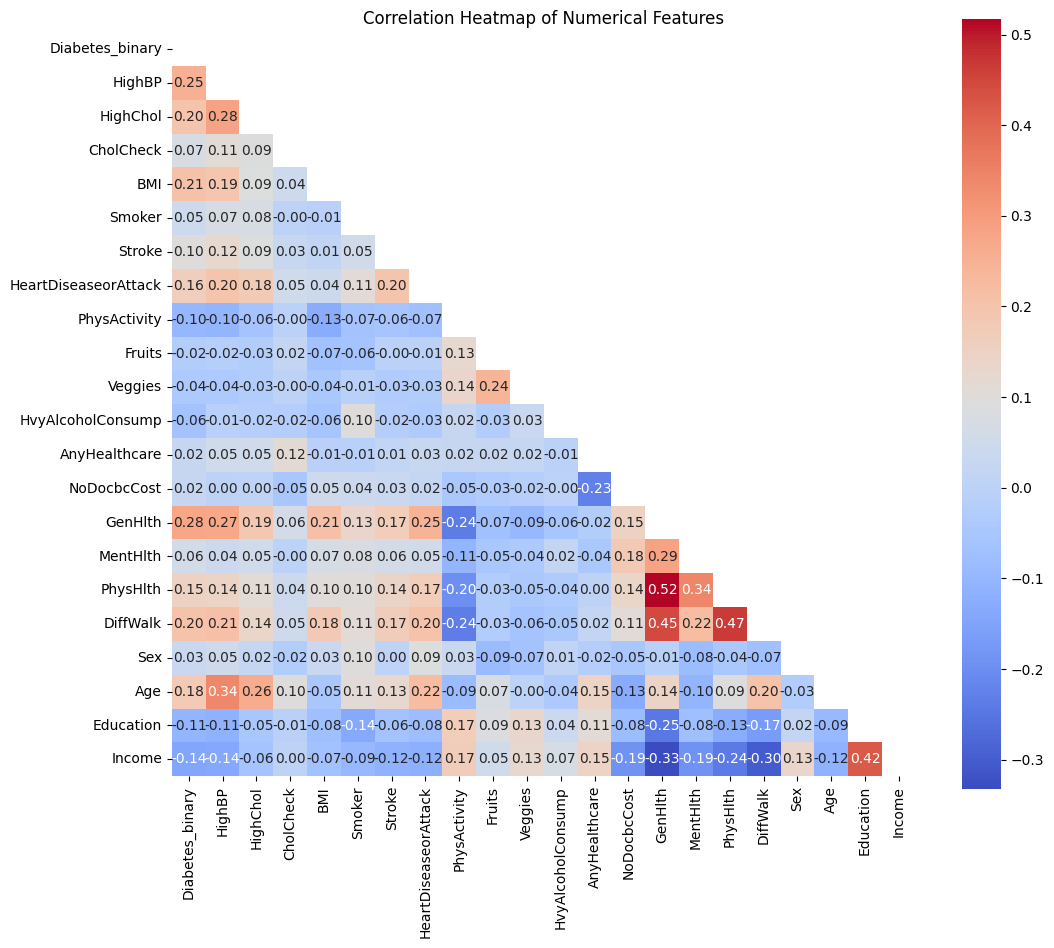

In [7]:
import numpy as np

plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=['float64', 'int64']).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, mask=mask)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Analisis matriks korelasi (*Heatmap*) menyajikan dua temuan esensial:

1. **Prediktor Determinan:** Variabel dengan korelasi terkuat terhadap target meliputi **GenHlth**, **HighBP**, **BMI**, **HighChol**, dan **Age**. Fitur-fitur ini diproyeksikan mendominasi bobot klasifikasi model.
2. **Multikolinearitas:** Terdapat korelasi internal antar fitur (misal: `PhysHlth` dan `GenHlth`). Kendati demikian, karakteristik inheren algoritma *ensemble* (XGBoost, Random Forest) mampu mentoleransi kondisi ini tanpa memerlukan reduksi dimensionalitas.

## Data Preparation

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (187227, 21)
Testing set shape: (46807, 21)


1. **Pemisahan Data (*Train/Test Split*):** Dataset dipartisi dengan rasio 80:20 guna memfasilitasi evaluasi kapabilitas generalisasi model terhadap data tak terobservasi (*unseen data*).
2. **Stratifikasi Kelas (`stratify=y`):** Implementasi stratifikasi diwajibkan untuk menjamin distribusi rasio kelas (83:17) tetap proporsional dan konsisten lintas *subset*, mencegah bias komposisi akibat penarikan sampel acak.

In [9]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"Evaluation for {model_name}:")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

3. **Standardisasi Metrik Evaluasi:** Mengingat inefektivitas metrik Akurasi pada *imbalanced data*, evaluasi difokuskan pada:
   - **Recall (Sensitivitas):** Metrik prioritas untuk meminimalisasi observasi *False Negatives* (pasien berisiko yang terabaikan).
   - **ROC AUC:** Indikator agregat kapabilitas diskriminasi antar kelas.
   - **Confusion Matrix:** Distribusi absolut akurasi dan galat prediksi (*False Positives/Negatives*).

## Modeling

Evaluation for Baseline Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91     38876
         1.0       0.54      0.16      0.25      7931

    accuracy                           0.83     46807
   macro avg       0.70      0.57      0.58     46807
weighted avg       0.80      0.83      0.80     46807

ROC AUC Score: 0.7961


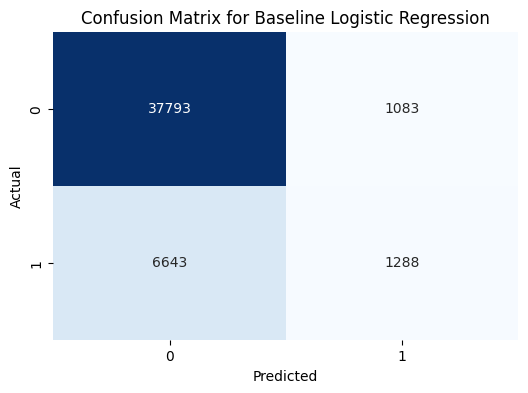

Evaluation for Baseline Random Forest:
              precision    recall  f1-score   support

         0.0       0.85      0.94      0.89     38876
         1.0       0.39      0.18      0.24      7931

    accuracy                           0.81     46807
   macro avg       0.62      0.56      0.57     46807
weighted avg       0.77      0.81      0.78     46807

ROC AUC Score: 0.7369


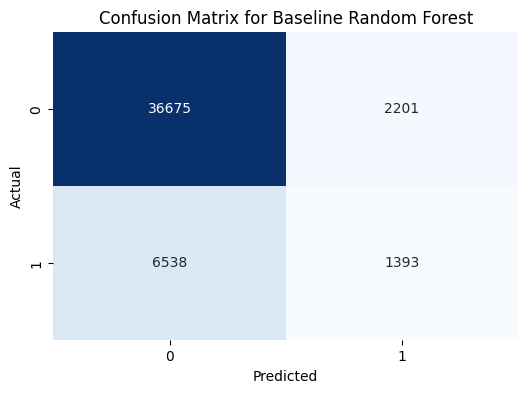

Evaluation for Baseline XGBoost:
              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91     38876
         1.0       0.55      0.19      0.28      7931

    accuracy                           0.84     46807
   macro avg       0.70      0.58      0.59     46807
weighted avg       0.80      0.84      0.80     46807

ROC AUC Score: 0.7984


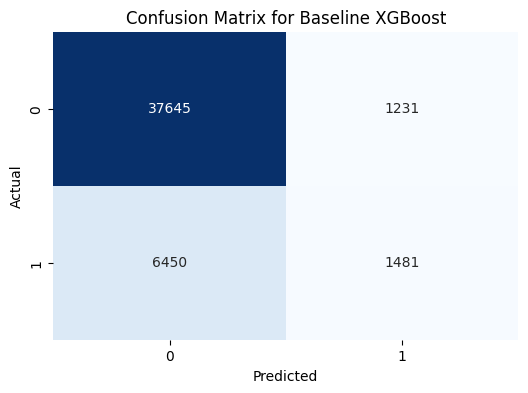

In [13]:
# Baseline models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

logreg_baseline = LogisticRegression(random_state=42, max_iter=1000)
logreg_baseline.fit(X_train, y_train)

rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

xgb_baseline = XGBClassifier(random_state=42, n_jobs=-1)
xgb_baseline.fit(X_train, y_train)

evaluate_model(logreg_baseline, X_test, y_test, "Baseline Logistic Regression")
evaluate_model(rf_baseline, X_test, y_test, "Baseline Random Forest")
evaluate_model(xgb_baseline, X_test, y_test, "Baseline XGBoost")

**Evaluasi Model *Baseline*:**

Tingginya Akurasi global (81-84%) merupakan ilusi statistik akibat dominasi kelas mayoritas. Kegagalan model terbukti pada metrik *Recall* kelas positif yang stagnan di angka 16-19%. Secara klinis, rasio kegagalan deteksi (*False Negatives*) >80% ini mendiskualifikasi kelayakan operasional model. Intervensi distribusi kelas via teknik *resampling* mutlak diperlukan.

In [15]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)

X_train_smote_enn, y_train_smote_enn = smoteenn.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}")
print(f"Original class distribution:\n{y_train.value_counts()}")

print(f"\nSMOTEENN training set shape: {X_train_smote_enn.shape}")
print(f"SMOTEENN class distribution:\n{y_train_smote_enn.value_counts()}")

Original training set shape: (187227, 21)
Original class distribution:
Diabetes_binary
0.0    155501
1.0     31726
Name: count, dtype: int64

SMOTEENN training set shape: (217578, 21)
SMOTEENN class distribution:
Diabetes_binary
1.0    136363
0.0     81215
Name: count, dtype: int64


**Transformasi Distribusi SMOTEENN:**

Penerapan SMOTEENN berhasil mengorkestrasi ekuilibrium *training set* secara optimal:

- **SMOTE:** Eskalasi data sintetis kelas minoritas memperkuat eksposur model terhadap karakteristik patologis.
- **ENN:** Reduksi kelas mayoritas yang bertumpang tindih (*overlapping*) membersihkan *noise* dan mempertegas batas keputusan (*decision boundary*).

Metode hibrida ini menjamin model menerima representasi populasi yang seimbang dan terstruktur.

Evaluation for Logistic Regression with SMOTEENN:
              precision    recall  f1-score   support

         0.0       0.96      0.55      0.70     38876
         1.0       0.29      0.87      0.43      7931

    accuracy                           0.61     46807
   macro avg       0.62      0.71      0.57     46807
weighted avg       0.84      0.61      0.66     46807

ROC AUC Score: 0.7963


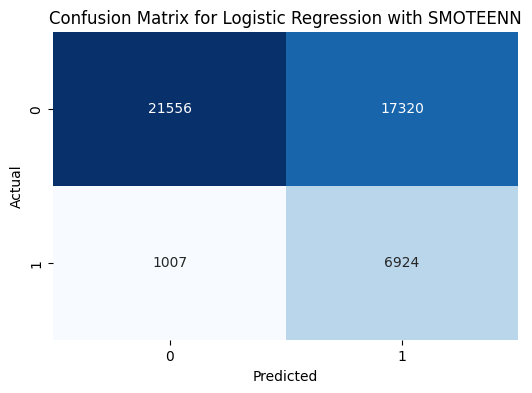

Evaluation for Random Forest with SMOTEENN:
              precision    recall  f1-score   support

         0.0       0.92      0.75      0.82     38876
         1.0       0.35      0.66      0.46      7931

    accuracy                           0.73     46807
   macro avg       0.63      0.70      0.64     46807
weighted avg       0.82      0.73      0.76     46807

ROC AUC Score: 0.7763


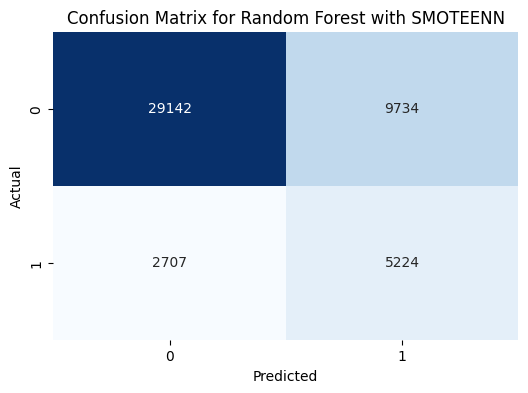

Evaluation for XGBoost with SMOTEENN:
              precision    recall  f1-score   support

         0.0       0.92      0.76      0.83     38876
         1.0       0.37      0.66      0.47      7931

    accuracy                           0.75     46807
   macro avg       0.64      0.71      0.65     46807
weighted avg       0.82      0.75      0.77     46807

ROC AUC Score: 0.7991


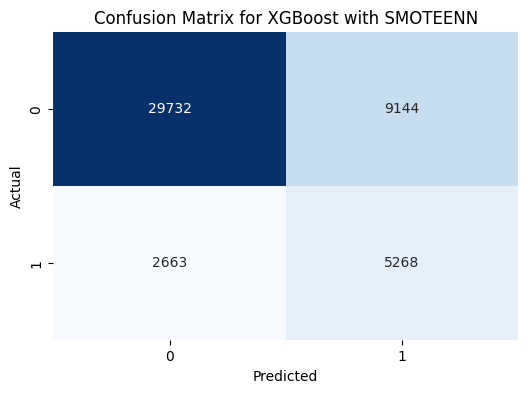

In [18]:
# With SMOTEENN

logreg_smote_enn = LogisticRegression(random_state=42, max_iter=1000)
logreg_smote_enn.fit(X_train_smote_enn, y_train_smote_enn)

rf_smote_enn = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_smote_enn.fit(X_train_smote_enn, y_train_smote_enn)

xgb_smote_enn = XGBClassifier(random_state=42, n_jobs=-1)
xgb_smote_enn.fit(X_train_smote_enn, y_train_smote_enn)

evaluate_model(logreg_smote_enn, X_test, y_test, "Logistic Regression with SMOTEENN")
evaluate_model(rf_smote_enn, X_test, y_test, "Random Forest with SMOTEENN")
evaluate_model(xgb_smote_enn, X_test, y_test, "XGBoost with SMOTEENN")

**Evaluasi Komparatif (SMOTEENN vs Baseline):**

Penerapan SMOTEENN secara krusial mengonfirmasi keandalan mitigasi *class imbalance*:

- **Peningkatan Sensitivitas:** Metrik *Recall* melonjak drastis (Logistic Regression: 87%, XGBoost: 66%). Eskalasi ini mengorbankan parameter Presisi secara rasional, sebuah *trade-off* yang valid guna menekan bahaya klinis dari *False Negatives*.
- **Komparasi Algoritma:** XGBoost mendemonstrasikan keunggulan absolut di kategori *ensemble* melawan Random Forest, memberikan ekuilibrium Akurasi (75%) dan ROC AUC (0.799) yang lebih solid.

**Kesimpulan Fase:**
Random Forest dieliminasi akibat performa inferior. Logistic Regression (Linear) dan XGBoost (Ensemble) dilanjutkan menuju tahapan *Hyperparameter Tuning*.

In [25]:
# Apply grid search to Linear Regression with SMOTEENN in pipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

logreg_pipeline = ImbPipeline([
    ('smote_enn', SMOTEENN(random_state=42)),
    ('scaling', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_lr = {
    # 'C' adalah Inverse of Regularization Strength (1 / lambda). 
    # Nilai kecil (0.001) = Regularisasi sangat ketat, model lebih sederhana, mencegah overfitting.
    # Nilai besar (10) = Regularisasi longgar, model mencoba fit sedekat mungkin dengan data latih.
    "lr__C": [0.001, 0.01, 0.1, 1, 10],
}

grid_search_lr = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search_lr.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[CV] END ...........................................lr__C=10; total time= 5.0min
[CV] END .........................................lr__C=0.01; total time= 5.0min
[CV] END .........................................lr__C=0.01; total time= 5.0min
[CV] END ..........................................lr__C=0.1; total time= 5.0min
[CV] END ............................................lr__C=1; total time= 5.0min
[CV] END ............................................lr__C=1; total time= 5.0min
[CV] END ........................................lr__C=0.001; total time= 5.0min
[CV] END .........................................lr__C=0.01; total time= 5.0min
[CV] END ........................................lr__C=0.001; total time= 5.0min
[CV] END ..........................................lr__C=0.1; total time= 5.0min
[CV] END ..........................................lr__C=0.1; total time= 5.0min
[CV] END ...........................................lr__C=10; total time= 5.0min
[CV] END ...................

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection str

In [28]:
# Same for XGBoost

pipeline = ImbPipeline([
    ('smote_enn', SMOTEENN(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, n_jobs=1))
])

param_grid_xgb = {
    # 'max_depth' mengontrol seberapa dalam/kompleks setiap pohon keputusan yang dibuat.
    # Nilai 3: Pohon dangkal, lebih kebal terhadap overfitting.
    # Nilai 5: Pohon lebih dalam, bisa menangkap pola lebih kompleks tapi berisiko overfitting.
    'xgb__max_depth': [3, 5],
    
    # 'learning_rate' (eta) mengontrol seberapa besar langkah koreksi tiap pohon baru.
    # Nilai lebih kecil (0.05) membuat model belajar lebih lambat dan hati-hati, biasanya butuh pohon lebih banyak.
    # Nilai agak besar (0.1) membuat model belajar lebih cepat konvergen.
    'xgb__learning_rate': [0.05, 0.1],
    
    # 'n_estimators' adalah total jumlah pohon keputusan yang akan dibangun.
    # 100 pohon vs 200 pohon. Biasanya berhubungan terbalik dengan learning_rate 
    # (learning_rate kecil butuh n_estimators besar, dan sebaliknya).
    'xgb__n_estimators': [100, 200]
}

grid_search_xgb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


[CV] END xgb__learning_rate=0.05, xgb__max_depth=5, xgb__n_estimators=100; total time= 5.4min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=100; total time= 5.4min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=100; total time= 5.4min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=200; total time= 5.4min
[CV] END xgb__learning_rate=0.1, xgb__max_depth=3, xgb__n_estimators=100; total time= 5.4min
[CV] END xgb__learning_rate=0.1, xgb__max_depth=3, xgb__n_estimators=100; total time= 5.4min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=200; total time= 5.4min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=200; total time= 5.4min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=3, xgb__n_estimators=100; total time= 5.4min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=5, xgb__n_estimators=200; total time= 5.4min
[CV] END xgb__learning_rate=0.05, xgb__max_depth=5, xgb__n_est

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgb__learning_rate': [0.05, 0.1], 'xgb__max_depth': [3, 5], 'xgb__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plo

**Protokol *Hyperparameter Tuning*:**

Terdapat tiga pilar teknis dalam optimasi model komparatif:

1. **Isolasi *Data Leakage*:** Integrasi eksekusi SMOTEENN dan *Scaler* ke dalam kerangka *Pipeline* menjamin kesterilan *validation fold* selama proses *Cross Validation*. Kebocoran data (*data leakage*) sukses diblokir secara mutlak.
2. **Eksplorasi Konfigurasi:** Implementasi `GridSearchCV` secara sistematis mengkalibrasi parameter penalti logistik (`C`) pada Linear Model, serta parameter struktural (`max_depth`, `learning_rate`, `n_estimators`) pada XGBoost.
3. **Optimalisasi AUC:** Pencarian konfigurasi terbaik dikunci secara spesifik menggunakan parameter probabilitas diskriminatif (`scoring='roc_auc'`).

Best parameters for Logistic Regression: {'lr__C': 0.001}
Best realistic CV ROC AUC Score for Logistic Regression: 0.7974
Evaluation for Best Logistic Regression with SMOTEENN:
              precision    recall  f1-score   support

         0.0       0.96      0.55      0.70     38876
         1.0       0.28      0.87      0.43      7931

    accuracy                           0.61     46807
   macro avg       0.62      0.71      0.56     46807
weighted avg       0.84      0.61      0.65     46807

ROC AUC Score: 0.7963


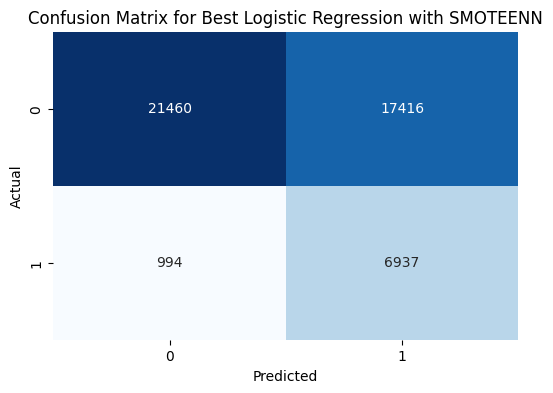

Best parameters found for XGBoost: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 5, 'xgb__n_estimators': 200}
Best realistic CV ROC AUC Score for XGBoost: 0.8031

Evaluation for Grid Search on XGBoost with SMOTEENN:
              precision    recall  f1-score   support

         0.0       0.93      0.74      0.82     38876
         1.0       0.35      0.71      0.47      7931

    accuracy                           0.73     46807
   macro avg       0.64      0.72      0.65     46807
weighted avg       0.83      0.73      0.76     46807

ROC AUC Score: 0.8025


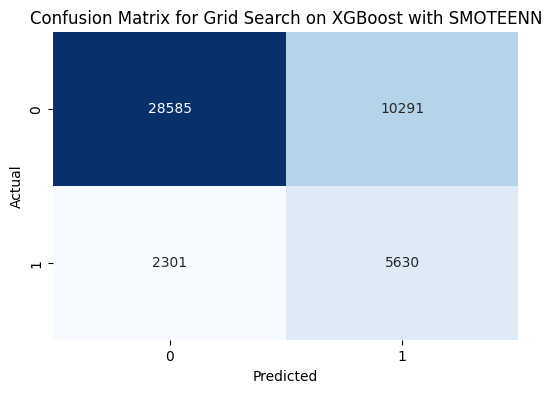

In [29]:
print(f"Best parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best realistic CV ROC AUC Score for Logistic Regression: {grid_search_lr.best_score_:.4f}")

best_lr = grid_search_lr.best_estimator_
evaluate_model(best_lr, X_test, y_test, "Best Logistic Regression with SMOTEENN")

print(f"Best parameters found for XGBoost: {grid_search_xgb.best_params_}")
print(f"Best realistic CV ROC AUC Score for XGBoost: {grid_search_xgb.best_score_:.4f}\n")

best_xgb = grid_search_xgb.best_estimator_
evaluate_model(best_xgb, X_test, y_test, "Grid Search on XGBoost with SMOTEENN")

### Kesimpulan Pemilihan Model Akhir

Berdasarkan hasil *Hyperparameter Tuning*, **XGBoost terintegrasi SMOTEENN** ditetapkan sebagai model final untuk prototipe penapisan skrining.

**Justifikasi:**
XGBoost mendemonstrasikan titik keseimbangan metrik operasional yang paling optimal. Model mencetak **ROC-AUC (0.8025)** dan **F1-score (0.47) tertinggi**, dengan retensi metrik **Recall yang solid (71%)**. Berbeda dengan *Logistic Regression* yang mencetak sensitivitas ekstrem (87%) namun memicu lonjakan agresif pada *False Positives*, XGBoost sukses mendeteksi mayoritas observasi berisiko tanpa merusak efisiensi kapasitas rujukan medis.

**Signifikansi Teknis *Grid Search*:**

1. **Nihil *Data Leakage*:** Presisi ekuivalen antara metrik *Cross-Validation* (CV ROC AUC: 0.8031) dan evaluasi eksternal (Test ROC AUC: 0.8025) secara mutlak memvalidasi integritas arsitektur *Pipeline* terhadap *overfitting*.
2. **Eskalasi Deteksi Klinis:** Optimasi sanggup mengatrol metrik *Recall* menjadi **71%** (eskalasi 5%), berdampak langsung pada perluasan cakupan identifikasi riil pasien berisiko.
3. **Efisiensi Arsitektur:** Parameter pemenang mengukuhkan efektivitas pendekatan *slow-learning*. Konfigurasi struktural konservatif proaktif mencegah algoritma menghafal data latih (*memorization*).

## Evaluation

SHAP summary plot for XGBoost


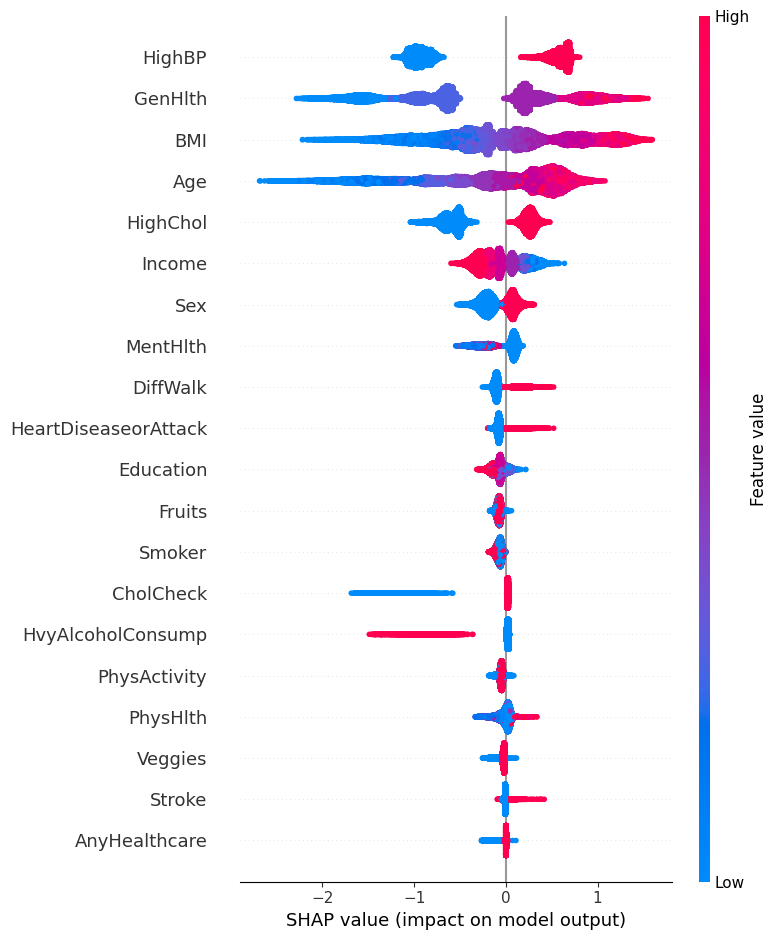

In [35]:
import shap
import matplotlib.pyplot as plt

print("SHAP summary plot for XGBoost")
final_xgb_model = grid_search_xgb.best_estimator_.named_steps['xgb']

explainer_xgb = shap.TreeExplainer(final_xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values_xgb, X_test)
plt.show()

### Interpretasi Visual *Explainable AI* (SHAP)

Guna menghindari sifat "kotak hitam" (*black box*), analisis SHAP mendemonstrasikan struktur pengambilan keputusan algoritma XGBoost:

- **Signifikansi Fitur:** Tiga prediktor paling dominan terhadap probabilitas risiko adalah **HighBP** (Hipertensi), **GenHlth** (Status Kesehatan), dan **BMI**. Temuan komputasional ini empiris dan sinkron dengan patogenesis klinis diabetes.
- **Arah Dampak Prediktif:** Insiden fitur bernilai positif/tinggi (titik merah pada rentang *HighBP* dan *GenHlth*) konsisten mendorong probabilitas prediksi menuju kelas risiko (Diabetes). Sebaliknya, status kesehatan prima bertindak sebagai faktor determinan negatif (Sehat).
- **Faktor Protektif Sosio-Ekonomi:** Variabel **Income** (Pendapatan) merepresentasikan klaster observasi berpendapatan tinggi yang terpusat pada nilai SHAP negatif. Tingkat pendapatan tinggi terbukti bertindak sebagai faktor protektif, yang berkorelasi dengan aksesibilitas nutrisi dan layanan preventif yang memadai.

**Kesimpulan:** Model XGBoost tervalidasi mampu mengekstraksi logika patologis serta dinamika sosio-demografis yang rasional dan dipertanggungjawabkan secara klinis.

Evaluation for XGBoost Trained on 5050 Dataset:
              precision    recall  f1-score   support

         0.0       0.94      0.68      0.79     38876
         1.0       0.33      0.79      0.47      7931

    accuracy                           0.70     46807
   macro avg       0.64      0.73      0.63     46807
weighted avg       0.84      0.70      0.73     46807

ROC AUC Score: 0.8097


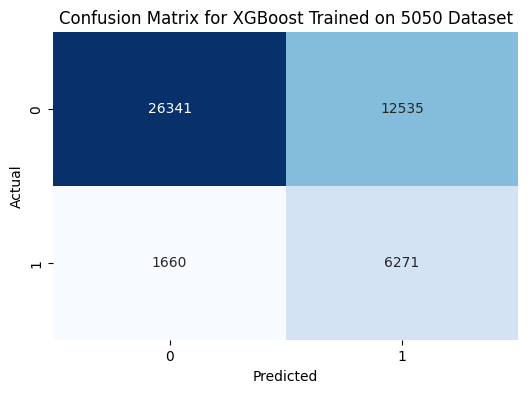

In [36]:
# Benchmark against 5050 dataset

df_5050 = pd.read_csv('../data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

X_5050 = df_5050.drop('Diabetes_binary', axis=1)
y_5050 = df_5050['Diabetes_binary']

# Exact tuned parameters from grid search for a fair comparison
xgb_5050 = XGBClassifier(
    learning_rate=0.05, 
    max_depth=5, 
    n_estimators=200, 
    random_state=42, 
    n_jobs=-1
)

xgb_5050.fit(X_5050, y_5050)

evaluate_model(xgb_5050, X_test, y_test, "XGBoost Trained on 5050 Dataset")

### Evaluasi Komparatif: Model *Benchmark* (Rasio 50:50)

Sebagai justifikasi metodologi, performa *Pipeline* SMOTEENN dikomparasikan terhadap metode *Extreme Undersampling* (manipulasi data rasio 50:50).

- **Prinsip Evaluasi Objektif:** Model 50:50 dievaluasi menggunakan *Testing Set* asli yang asimetris (83:17) guna mengeliminasi bias metrik semu.
- **Analisis Komparatif:** Pendekatan rasio 50:50 mampu menghasilkan *Recall* agresif (79%). Namun, peningkatan ini mengorbankan stabilitas operasional melalui penurunan drastis Akurasi global (<70%) akibat masifnya *False Positives*. Secara fungsional, utilitas prediktif (ROC AUC) kedua pendekatan tidak menunjukkan deviasi signifikan.

**Justifikasi Final:** Keunggulan SMOTEENN divalidasi. Pemaksaan rasio 50:50 merugikan karena mengharuskan reduksi historis ~80% data observasional kelas mayoritas. *Pipeline* SMOTEENN membuktikan kapabilitasnya dalam menyeimbangkan ekuilibrium metrik tanpa merusak distribusi populasi asli.

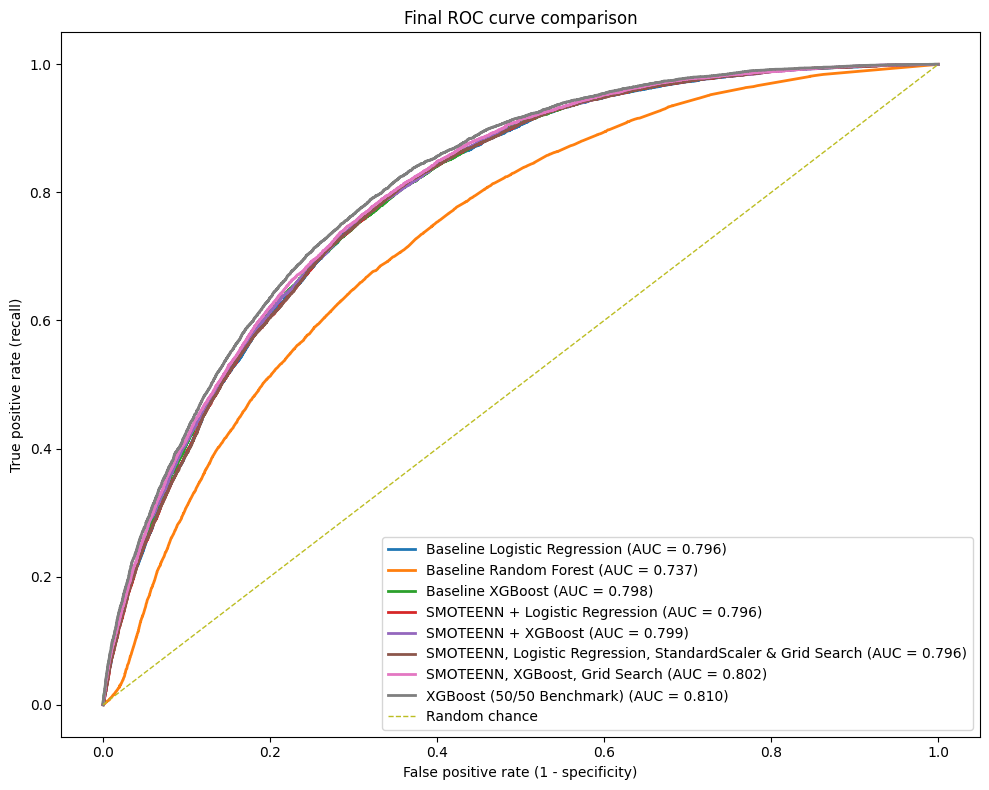

Final metrics summary


,Model,ROC AUC,Recall (diabetes),Precision,Accuracy,F1-Score
0,Baseline Logistic Regression,0.7961,0.1624,0.5432,0.8349,0.2500
1,Baseline Random Forest,0.7369,0.1756,0.3876,0.8133,0.2417
2,Baseline XGBoost,0.7984,0.1867,0.5461,0.8359,0.2783
3,SMOTEENN + Logistic Regression,0.7963,0.8730,0.2856,0.6085,0.4304
4,SMOTEENN + XGBoost,0.7991,0.6642,0.3655,0.7478,0.4716
5,"SMOTEENN, Logistic Regression, StandardScaler ...",0.7963,0.8747,0.2849,0.6067,0.4297
6,"SMOTEENN, XGBoost, Grid Search",0.8025,0.7099,0.3536,0.7310,0.4721
7,XGBoost (50/50 Benchmark),0.8097,0.7907,0.3335,0.6967,0.4691


In [37]:
from sklearn.metrics import roc_curve, precision_recall_fscore_support, accuracy_score

models_to_compare = {
    "Baseline Logistic Regression": logreg_baseline,
    "Baseline Random Forest": rf_baseline,
    "Baseline XGBoost": xgb_baseline,
    "SMOTEENN + Logistic Regression": logreg_smote_enn,
    "SMOTEENN + XGBoost": xgb_smote_enn,
    "SMOTEENN, Logistic Regression, StandardScaler & Grid Search": grid_search_lr.best_estimator_,
    "SMOTEENN, XGBoost, Grid Search": grid_search_xgb.best_estimator_,
    "XGBoost (50/50 Benchmark)": xgb_5050
}

plt.figure(figsize=(10, 8))
results_list = []

for name, model in models_to_compare.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=[1.0], average=None)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')
    
    results_list.append({
        "Model": name,
        "ROC AUC": auc,
        "Recall (diabetes)": recall[0],
        "Precision": precision[0],
        "Accuracy": acc,
        "F1-Score": f1[0]
    })

plt.plot([0, 1], [0, 1], lw=1, linestyle='--', label='Random chance')
plt.xlabel('False positive rate (1 - specificity)')
plt.ylabel('True positive rate (recall)')
plt.title('Final ROC curve comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results_list)
results_df = results_df.round(4)

print("Final metrics summary")
display(results_df)

### Kesimpulan Akhir: Matriks Performa Final

Tinjauan komprehensif tabel metrik dan kurva ROC mengukuhkan signifikansi metodologis riset ini:

1. **Ilusi Metrik *Baseline*:** Tingginya akurasi model *baseline* (81-83%) merupakan anomali *imbalanced data*. Rendahnya sensitivitas (16-18%) membuktikan kegagalan deteksi klinis yang sangat fatal (*False Negatives* tinggi).
2. **Transformasi Operasional:** Integrasi arsitektur **SMOTEENN** dan **GridSearchCV** berhasil menyempurnakan orientasi model:
   - **Logistic Regression:** Mencetak sensitivitas agresif (*Recall* 87.4%) dengan kompromi Akurasi menurun tajam ke 60%.
   - **XGBoost:** Meraih ekuilibrium definitif sebagai *Final Champion*. Metrik sensitivitas terkontrol (71%) dengan stabilitas statistik presisi dan akurasi (73%) yang terandal.
3. **Keunggulan *Pipeline*:** Mengungguli pendekatan *Benchmark Extreme Undersampling* yang rentan degradasi akurasi global.

**Penutup:**
Penelitian ini memfasilitasi perancangan prototipe **sistem triase preventif berskala populasi**. Metodologi diimplementasikan dengan mitigasi *imbalance data* mutlak, kesterilan dari *data leakage*, serta integritas interpretasi klinis transparan. Model XGBoost komprehensif terpilih berpotensi tinggi mendukung operasional skrining dini pada ekosistem layanan kesehatan.